# SIOC 251 – Homework 3 Monte Carlo Scattering PartIII

**Name:** Claire Liu   
**Date:** 5/28/26

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Model 

In [1]:
def monte_carlo_cloud(n_photons, tau_above, tau_cloud, tau_below, 
                       omega_clear=1.0, omega_cloud=1.0, 
                       g_clear=0.0, g_cloud=0.8,
                       mu0=1.0, z_top=10.0, z_cloud_top=1.0, z_cloud_base=0.75):
    """
    Three-layer atmosphere:
      Layer 1: Clear sky above cloud (z_cloud_top to z_top)
      Layer 2: Cloud layer (z_cloud_base to z_cloud_top)
      Layer 3: Clear sky below cloud (0 to z_cloud_base)
    Surface is perfectly absorbing (albedo = 0).
    Clear sky scattering is isotropic (g=0).
    """
    
    n_direct = 0
    n_diffuse = 0
    n_reflected = 0
    n_absorbed_atm = 0
    
    for i in range(n_photons):
        # Initial direction
        theta = np.arccos(mu0)
        phi_dir = 0.0
        kx = np.cos(phi_dir) * np.sin(theta)
        ky = np.sin(phi_dir) * np.sin(theta)
        kz = -np.cos(theta)
        
        z = z_top
        n_scatters = 0
        alive = True
        
        while alive:
            # Determine which layer the photon is in
            if z > z_cloud_top:
                tau_layer = tau_above
                z_layer_top = z_top
                z_layer_bot = z_cloud_top
                omega = omega_clear
                g = g_clear
            elif z > z_cloud_base:
                tau_layer = tau_cloud
                z_layer_top = z_cloud_top
                z_layer_bot = z_cloud_base
                omega = omega_cloud
                g = g_cloud
            else:
                tau_layer = tau_below
                z_layer_top = z_cloud_base
                z_layer_bot = 0.0
                omega = omega_clear
                g = g_clear
            
            # Physical thickness of this layer
            dz_layer = z_layer_top - z_layer_bot
            
            # Distance per unit optical depth in this layer
            if tau_layer > 1e-10:
                dz_per_tau = dz_layer / tau_layer
            else:
                # Essentially transparent layer — photon passes through
                if kz < 0:
                    z = z_layer_bot - 1e-10  # move to next layer down
                else:
                    z = z_layer_top + 1e-10  # move to next layer up
                # Check boundaries
                if z >= z_top:
                    n_reflected += 1
                    alive = False
                elif z <= 0:
                    if n_scatters == 0:
                        n_direct += 1
                    else:
                        n_diffuse += 1
                    alive = False
                continue
            
            # Sample optical path length
            delta_tau = -np.log(np.random.uniform())
            ds = delta_tau * dz_per_tau
            
            # Move photon
            z_new = z + kz * ds
            
            # Check if photon leaves current layer
            if z_new > z_layer_top:
                z = z_layer_top + 1e-10  # enter layer above
                if z >= z_top:
                    n_reflected += 1
                    alive = False
                continue
            elif z_new < z_layer_bot:
                z = z_layer_bot - 1e-10  # enter layer below
                if z <= 0:
                    if n_scatters == 0:
                        n_direct += 1
                    else:
                        n_diffuse += 1
                    alive = False
                continue
            else:
                # Interaction within this layer
                z = z_new
                
                if np.random.uniform() < omega:
                    n_scatters += 1
                    
                    # HG scattering angle
                    zeta = np.random.uniform()
                    if abs(g) < 1e-10:
                        cos_Theta = 2 * zeta - 1
                    else:
                        s = (1 - g**2) / (1 - g + 2 * g * zeta)
                        cos_Theta = (1 + g**2 - s**2) / (2 * g)
                    cos_Theta = max(-1.0, min(1.0, cos_Theta))
                    
                    sin_Theta = np.sqrt(1 - cos_Theta**2)
                    Phi = 2 * np.pi * np.random.uniform()
                    
                    kp_x = sin_Theta * np.cos(Phi)
                    kp_y = sin_Theta * np.sin(Phi)
                    kp_z = cos_Theta
                    
                    zp = np.array([kx, ky, kz])
                    kxy = np.sqrt(kx**2 + ky**2)
                    if kxy > 1e-8:
                        xp = np.array([-ky, kx, 0.0]) / kxy
                    else:
                        xp = np.array([1.0, 0.0, 0.0])
                    yp = np.cross(zp, xp)
                    
                    k_new = kp_x * xp + kp_y * yp + kp_z * zp
                    k_new = k_new / np.linalg.norm(k_new)
                    kx, ky, kz = k_new
                else:
                    n_absorbed_atm += 1
                    alive = False
    
    return {
        'direct_T': n_direct / n_photons,
        'diffuse_T': n_diffuse / n_photons,
        'total_T': (n_direct + n_diffuse) / n_photons,
        'albedo': n_reflected / n_photons,
        'absorptance': n_absorbed_atm / n_photons,
    }

### 7.1c

In [22]:
# --- Cloud optical depth calculation
LWC = 0.30e-3            # liquid water content: 0.30 g/m³ = 0.30e-3 kg/m³
dz_cloud = 250           # cloud thickness: 250 m
rho_w = 1000              # water density: 1000 kg/m³
r_eff = 11e-6            # effective radius: 11 μm

tau_cloud = (3 * LWC * dz_cloud) / (2 * rho_w * r_eff)
print(f"Cloud optical depth: {tau_cloud:.2f}")

Cloud optical depth: 10.23


In [23]:
H = 8.5  # km
P_top = np.exp(-10 / H)      # pressure at TOA (~0 km reference is surface)
P_cloud_top = np.exp(-1 / H)
P_cloud_base = np.exp(-0.75 / H)
P_surface = 1.0

tau_total_clear = 0.1  

# Fraction of atmosphere in each layer by pressure
frac_above = (P_cloud_top - P_top) / (P_surface - P_top)
frac_below = (P_surface - P_cloud_base) / (P_surface - P_top)

tau_above = tau_total_clear * frac_above
tau_below = tau_total_clear * frac_below

print(f"Clear sky tau above cloud: {tau_above:.4f}")
print(f"Clear sky tau below cloud: {tau_below:.4f}")

Clear sky tau above cloud: 0.0840
Clear sky tau below cloud: 0.0122


### 7.2 Verifications

**For a clear sky with no cloud, the albedo should be close to 0.**

In [15]:
n_photons = 100000
clear = monte_carlo_cloud(n_photons, tau_above=0.0840, tau_cloud=0.0, tau_below=0.0122,
                           omega_clear=1.0, g_clear=0.0)
print(clear)

{'direct_T': 0.90661, 'diffuse_T': 0.04647, 'total_T': 0.95308, 'albedo': 0.04692, 'absorptance': 0.0}


**For extremely optically think cloud, the albedo should be close to 1.**

In [18]:
n_photons = 1000
thick_cld = monte_carlo_cloud(n_photons, tau_above=0.0840, tau_cloud=1000, tau_below=0.0122,
                           omega_clear=1.0, g_clear=0.0)
print(thick_cld)

{'direct_T': 0.0, 'diffuse_T': 0.007, 'total_T': 0.007, 'albedo': 0.993, 'absorptance': 0.0}


In [19]:
# --- 7.3a: SW Cloud Radiative Effect ---
n_photons = 100000
mu0 = 1.0
S0 = 1361  # solar constant W/m²

# Clear sky run (no cloud)
clear = monte_carlo_cloud(n_photons, tau_above, 0.0, tau_below,
                           omega_clear=1.0, g_clear=0.0,
                           mu0=mu0)

# Cloudy sky run
cloudy = monte_carlo_cloud(n_photons, tau_above, tau_cloud, tau_below,
                            omega_clear=1.0, omega_cloud=1.0,
                            g_clear=0.0, g_cloud=0.85,
                            mu0=mu0)

# CRE = upward SW flux (clear) - upward SW flux (cloudy) at TOA
# Since surface absorbs everything, upward flux at TOA = albedo * S0 * mu0
# CRE_SW = (alpha_cloudy - alpha_clear) * S0 * mu0
CRE = (clear['albedo'] - cloudy['albedo']) * S0 * mu0

print(f"Clear sky albedo:  {clear['albedo']:.4f}")
print(f"Cloudy sky albedo: {cloudy['albedo']:.4f}")
print(f"SW CRE at TOA:     {CRE:.1f} W/m²")

Clear sky albedo:  0.0457
Cloudy sky albedo: 0.4494
SW CRE at TOA:     -549.4 W/m²


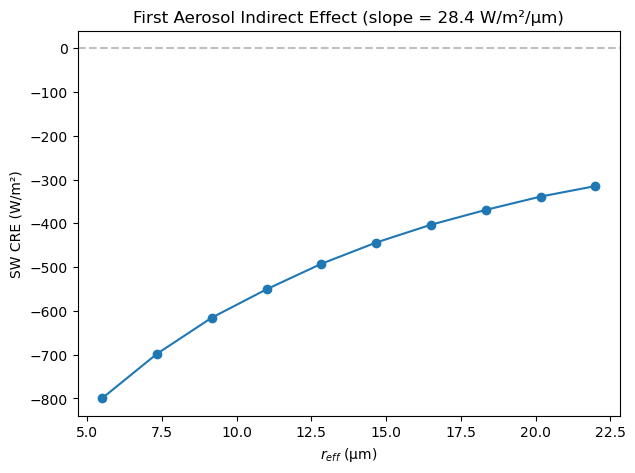

Slope: 28.4 W/m²/μm


In [20]:
# --- 7.3b: First aerosol indirect effect ---
# Vary r_eff from half to double, holding LWC and geometry constant

r_effs = np.linspace(r_eff * 0.5, r_eff * 2.0, 10)
CREs = []

for r in r_effs:
    tau_c = (3  * LWC * dz_cloud) / (2 * rho_w * r)
    result = monte_carlo_cloud(n_photons, tau_above, tau_c, tau_below,
                                omega_clear=1.0, omega_cloud=1.0,
                                g_clear=0.0, g_cloud=0.85,
                                mu0=mu0)
    CRE_val = (clear['albedo'] - result['albedo']) * S0 * mu0
    CREs.append(CRE_val)

CREs = np.array(CREs)
r_effs_um = r_effs * 1e6  # convert to μm

# Linear fit for slope
slope = np.polyfit(r_effs_um, CREs, 1)[0]

plt.figure(figsize=(7, 5))
plt.plot(r_effs_um, CREs, 'o-', color='tab:blue')
plt.xlabel(r'$r_{eff}$ (μm)')
plt.ylabel('SW CRE (W/m²)')
plt.title(f'First Aerosol Indirect Effect (slope = {slope:.1f} W/m²/μm)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.savefig('figures/aerosol_indirect_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Slope: {slope:.1f} W/m²/μm")

With smaller effctive radius(more smaller particles in the cloud), they scatter more radiation ann increase the albedo of the cloud, therefore leading to more cooling. 

### 7.3c

Questions: At what range of effective radius does the first aerosol indirect effect start to saturate? Where is it the strongest?

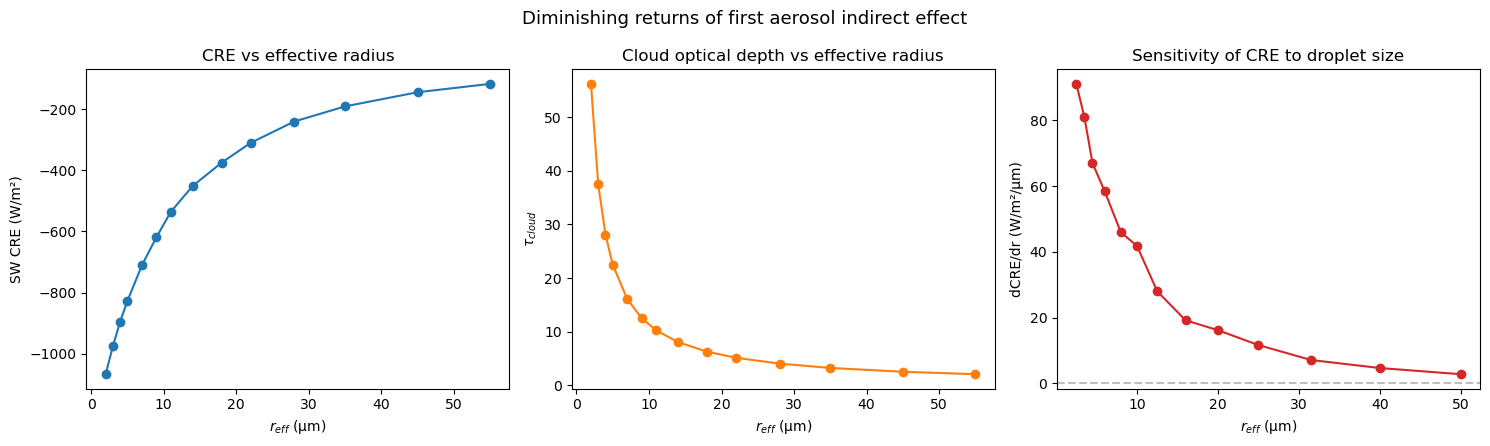

In [26]:
# --- Diminishing returns of first aerosol indirect effect ---

n_photons = 100000
mu0 = 1.0
S0 = 1361

# Wide range of r_eff
r_effs = np.array([2, 3, 4, 5, 7, 9, 11, 14, 18, 22, 28, 35, 45, 55]) * 1e-6

CREs = []
taus = []

for r in r_effs:
    tau_c = (3 * Q_ext * LWC * dz_cloud) / (4 * rho_w * r)
    taus.append(tau_c)
    
    # Use fewer photons for thick clouds
    n = 5000 if tau_c > 50 else 50000
    
    result = monte_carlo_cloud(n, tau_above, tau_c, tau_below,
                                omega_clear=1.0, omega_cloud=1.0,
                                g_clear=0.0, g_cloud=0.85, mu0=mu0)
    CRE_val = (clear['albedo'] - result['albedo']) * S0 * mu0
    CREs.append(CRE_val)

CREs = np.array(CREs)
taus = np.array(taus)
r_effs_um = r_effs * 1e6

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(r_effs_um, CREs, 'o-', color='tab:blue')
axes[0].set_xlabel(r'$r_{eff}$ (μm)')
axes[0].set_ylabel('SW CRE (W/m²)')
axes[0].set_title('CRE vs effective radius')

axes[1].plot(r_effs_um, taus, 'o-', color='tab:orange')
axes[1].set_xlabel(r'$r_{eff}$ (μm)')
axes[1].set_ylabel(r'$\tau_{cloud}$')
axes[1].set_title('Cloud optical depth vs effective radius')

# Local slope (dCRE/dr_eff) as measure of indirect effect strength
dCRE = np.diff(CREs)
dr = np.diff(r_effs_um)
slope_local = dCRE / dr
r_mid = (r_effs_um[:-1] + r_effs_um[1:]) / 2

axes[2].plot(r_mid, slope_local, 'o-', color='tab:red')
axes[2].set_xlabel(r'$r_{eff}$ (μm)')
axes[2].set_ylabel('dCRE/dr (W/m²/μm)')
axes[2].set_title('Sensitivity of CRE to droplet size')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Diminishing returns of first aerosol indirect effect', fontsize=13)
plt.tight_layout()
plt.savefig('figures/diminishing_indirect_effect.png', dpi=150, bbox_inches='tight')
plt.show()

CRE gets more negative as r_eff decreases, following a shape consistent with the 1/r_eff dependence of cloud optical depth. The middle panel confirms that τ_cloud increases sharply at small r_eff. The sensitivity dCRE/dr (right panel) is highest at the smallest droplet sizes and decreases smoothly toward larger r_eff. Above about 25-30 μm the sensitivity is near zero because the cloud is optically thin. So the indirect effect is always stronger at smaller r_eff, there's no clear saturation point within this range.

# AI Usage
Tool used: Claude

How it was used: I used Claude to make the functions and the plots.

What I changed: I went over the code, modified the parameters for the plots and interpreted the plots to answer the questions.

How I verified the result: I verifed the results by looking at the calculated albedo of clear sky(no cloud) and extremely optially thick cloud.
